**Bonus Question 5**

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv


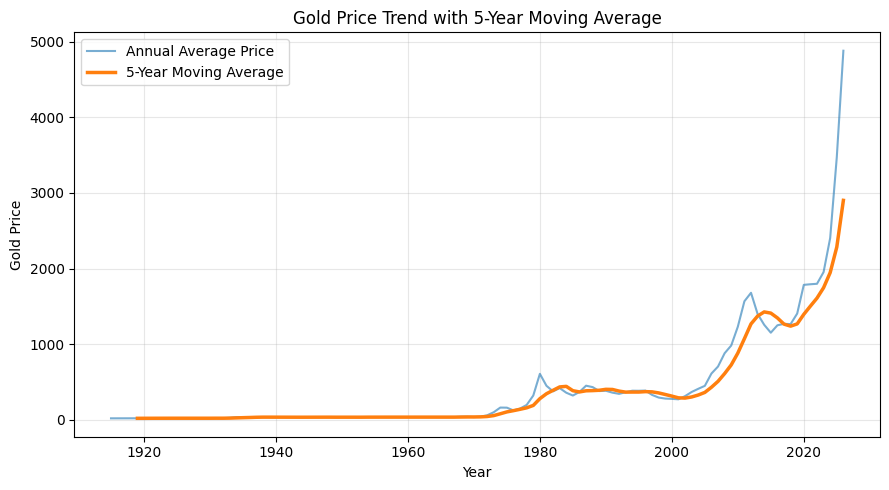

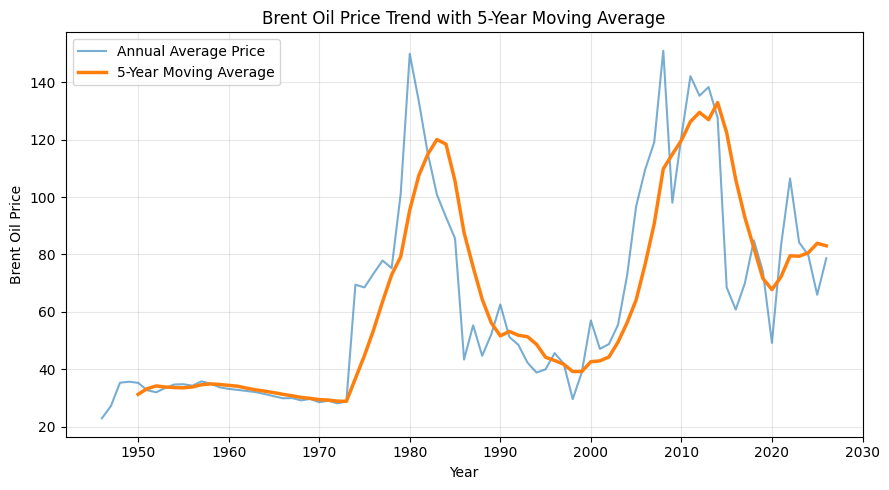

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def prepare_data(file_name):
    data = pd.read_csv(file_name)
    data["Date"] = pd.to_datetime(data["Date"], dayfirst=True)
    data["Value"] = pd.to_numeric(data["Value"], errors="coerce")
    data["Year"] = data["Date"].dt.year

    annual = data.groupby("Year")["Value"].mean().reset_index()
    annual["5-Year Moving Average"] = annual["Value"].rolling(window=5).mean()

    return annual

gold = prepare_data("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv")
brent = prepare_data("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv")

plt.figure(figsize=(9, 5))
plt.plot(gold["Year"], gold["Value"], label="Annual Average Price", alpha=0.6)
plt.plot(
    gold["Year"],
    gold["5-Year Moving Average"],
    label="5-Year Moving Average",
    linewidth=2.5
)
plt.title("Gold Price Trend with 5-Year Moving Average")
plt.xlabel("Year")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Gold_Moving_Average.pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(brent["Year"], brent["Value"], label="Annual Average Price", alpha=0.6)
plt.plot(
    brent["Year"],
    brent["5-Year Moving Average"],
    label="5-Year Moving Average",
    linewidth=2.5
)
plt.title("Brent Oil Price Trend with 5-Year Moving Average")
plt.xlabel("Year")
plt.ylabel("Brent Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Brent_Oil_Moving_Average.pdf", format="pdf", bbox_inches="tight")
plt.show()